# Problem Formulation: Predicting the Risk of Energy Poverty in Developing Areas

## Problem Statement

Globally, more than 700 million people do not have access to electricity, which is a major obstacle to advancements in education, healthcare, and the economy. Most of the current approaches to addressing energy poverty are reactive and rely on outdated annual surveys and reports that are unable to pinpoint the most important areas that require intervention.

Using historical economic, demographic, and infrastructure data from 1990 to 2020, we aim to forecast which nations will have energy poverty (electricity access <90%) between 2024 and 2027. In order to facilitate data-driven resource allocation by international development organizations, the model will categorize nations into three risk categories: severe, moderate, and minimal.

## Central Question

**Using historical trends in infrastructure development, demographic shifts, and economic indicators from 1990 to 2020, can we forecast which countries will face electricity access challenges?**

## Secondary questions
- Which variables—GDP, urbanization, and population density—correlate most strongly with a rise or drop in energy access?
- Is it possible to group nations into significant risk categories (severe, moderate, and minimal) in order to help prioritize tasks?

## Problem Type

This is essentially a **supervised learning problem** that combines:
- **Prediction**: Predicting the percentages of continuous electricity access
- **Classification**: classifying nations into risk categories for energy poverty
- **Exploration**: Finding the main underlying factors and trends in energy access

## Inputs (Features)

The following predictor variables from World Bank datasets will be used in the model:

*Economic Indicators:*
- GDP per capita (Current USD)

*Demographic Indicators:*
- Urban population (% of total)
- Rural population (% of total)
- Population density (persons/km²)
- Total population

*Structural Variables:*
- Year (1990-2023)
- Country/Region (ISO codes)

*Source: World Bank World Development Indicators*

## Time horizon

**Training:** 1990-2020 historical data 

**Prediction:** 2024-2027 (one to three years forecast) 

**Validation:** Make predictions for 2021–2023 based on data from 1990–2020 (accuracy check)

## Outputs (Target Variable)

**Primary Output:** 
- Predicted rates of access to electricity (%) for each country in 2024–2027

**Classification Output:**
- Risk categories for energy poverty: Severe (<50%), Moderate (50-89%), Minimal (90-99%) 
 
**Actionable Outputs:** 
- Ranked list of the ten to twenty greatest risk nations that need intervention 
- The top three to five feature importances (which factors matter most) 
- Confidence intervals for every forecast 
- Regional trends and patterns

## Success Criteria

The project will be considered successful if:

1. **Prediction Accuracy**:  The model predicts risk categories with at least 75% classification accuracy on held-out test data.

2. **Temporal Validation**: Using a model trained on data from 1990 to 2020, the model can accurately predict electricity access rates in 2021–2023 (demonstrates true forecasting ability).

3. **Interpretability**: We are able to identify and define the top three to five characteristics that have the biggest impact on forecasts of energy poverty.

4. **Actionability**: The model generates a prioritized list of ten to fifteen nations that need immediate intervention, with a detailed explanation based on anticipated risk factors.


### Import required Libraries

In [328]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scipy
%pip install scikit-learn


import pandas as pd
from matplotlib import pyplot as plt 
import numpy as np
import sqlite3
import seaborn as sns
from scipy.spatial.distance import euclidean, pdist, squareform
from sklearn.preprocessing import StandardScaler


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Data Aquisition 

In [329]:

# Load raw dataset
electricity_access_df = pd.read_csv("data/raw/1.AccessToElectricityAPI_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63.csv", skiprows=4)
gdp_df = pd.read_csv("data/raw/2.GDPAPI_NY.GDP.PCAP.CD_DS2_en_csv_v2_31/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv", skiprows=4)
urban_population_df = pd.read_csv("data/raw/3.UrbanAPI_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608.csv", skiprows=4)
rural_population_df = pd.read_csv("data/raw/4.RuralAPI_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502/API_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502.csv", skiprows=4)
population_density_df = pd.read_csv("data/raw/5.PopulationDensityAPI_EN.POP.DNST_DS2_en_csv_v2_275/API_EN.POP.DNST_DS2_en_csv_v2_275.csv", skiprows=4)
total_population_df = pd.read_csv("data/raw/6.TotalPopulationAPI_SP.POP.TOTL_DS2_en_csv_v2_7/API_SP.POP.TOTL_DS2_en_csv_v2_7.csv", skiprows=4)
renewable_energy_df = pd.read_csv("data/raw/7.RenewableEnergyAPI_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409.csv", skiprows=4)
government_effectiveness_df = pd.read_csv("data/raw/8.GovernmentEffectivenessAPI_GE.EST_DS2_en_csv_v2_2683/API_GE.EST_DS2_en_csv_v2_2683.csv", skiprows=4)

# Display the first few rows of each dataset to verify successful loading
print("Electricity Access Dataset:")
print(electricity_access_df.head())
print("\nGDP Dataset:")
print(gdp_df.head())
print("\nUrban Population Dataset:")
print(urban_population_df.head())
print("\nRural Population Dataset:")
print(rural_population_df.head())
print("\nPopulation Density Dataset:")
print(population_density_df.head())
print("\nTotal Population Dataset:")
print(total_population_df.head())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.head())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.head())

Electricity Access Dataset:
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                            Indicator Name  Indicator Code  1960  1961  1962  \
0  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
1  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
2  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
3  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
4  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   

   1963  1964  1965  ...        2016        2017        2018        2019  \
0   NaN   NaN   NaN  ...  100.000000  100.000000  100.000000  100.000000   
1   NaN   NaN   NaN  ...   38.859598   40.223744   43.03

In [330]:
# Check dataframe structure, column types, and missing values
print("Electricity Access Dataset:")
print(electricity_access_df.info())
print("\nGDP Dataset:")
print(gdp_df.info())
print("\nUrban Population Dataset:")
print(urban_population_df.info())
print("\nRural Population Dataset:")
print(rural_population_df.info())
print("\nPopulation Density Dataset:")
print(population_density_df.info())
print("\nTotal Population Dataset:")
print(total_population_df.info())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.info())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.info())

Electricity Access Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 

In [331]:
# Quick overview of distributions and ranges of numerical data
print("Electricity Access Dataset:")
print(electricity_access_df.describe())
print("\nGDP Dataset:")
print(gdp_df.describe())
print("\nUrban Population Dataset:")
print(urban_population_df.describe())
print("\nRural Population Dataset:")
print(rural_population_df.describe())
print("\nPopulation Density Dataset:")
print(population_density_df.describe())
print("\nTotal Population Dataset:")
print(total_population_df.describe())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.describe())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.describe())

Electricity Access Dataset:
       1960  1961  1962  1963  1964  1965  1966  1967  1968  1969  ...  \
count   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
mean    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
std     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
min     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
25%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
50%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
75%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
max     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

             2016        2017        2018        2019        2020        2021  \
count  263.000000  263.000000  263.000000  263.000000  263.000000  263.000000   
mean    83.819459   84.566219   85.202457   85.759857   86.293403   86.855188   
std     25.496742   24.937006   24.083577   23.831564   23.429

In [332]:
# Inspect missing data and number of unique countries
print("Electricity Access Dataset:")
print(electricity_access_df.isnull().sum())
print(electricity_access_df['Country Code'].nunique())
print("\nGDP Dataset:")
print(gdp_df.isnull().sum())
print(gdp_df['Country Code'].nunique())
print("\nUrban Population Dataset:")
print(urban_population_df.isnull().sum())
print(urban_population_df['Country Code'].nunique())
print("\nRural Population Dataset:")
print(rural_population_df.isnull().sum())
print(rural_population_df['Country Code'].nunique())
print("\nPopulation Density Dataset:")
print(population_density_df.isnull().sum())
print(population_density_df['Country Code'].nunique())
print("\nTotal Population Dataset:")
print(total_population_df.isnull().sum())
print(total_population_df['Country Code'].nunique())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.isnull().sum())
print(renewable_energy_df['Country Code'].nunique())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.isnull().sum())
print(government_effectiveness_df['Country Code'].nunique())

Electricity Access Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              266
                 ... 
2021                3
2022                3
2023                3
2024              266
Unnamed: 69       266
Length: 70, dtype: int64
266

GDP Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              115
                 ... 
2021                8
2022                9
2023               15
2024               26
Unnamed: 69       266
Length: 70, dtype: int64
266

Urban Population Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960                1
                 ... 
2021                1
2022                1
2023                1
2024                1
Unnamed: 69       266
Length: 70, dtype: int64
266

Rural Population Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
196

## Data Aquisition II (Database Storage)

In [333]:
# Reshape datasets from wide to long format
electricity_access_df_long = electricity_access_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="year",
    value_name="electricity_access"
)
gdp_df_long = gdp_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],      
    var_name="year",
    value_name="gdp_per_capita"
)
urban_population_df_long = urban_population_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],  
    var_name="year",
    value_name="urban_population_percent"
)
rural_population_df_long = rural_population_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="year",
    value_name="rural_population_percent"
)
population_density_df_long = population_density_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],      
    var_name="year",
    value_name="population_density"
)
total_population_df_long = total_population_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="year",
    value_name="total_population"
)
renewable_energy_df_long = renewable_energy_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],  
    var_name="year",
    value_name="renewable_energy_percent"
)
government_effectiveness_df_long = government_effectiveness_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],      
    var_name="year",
    value_name="government_effectiveness"
)
# Merge all datasets into a single dataframe for modeling

merged_df = electricity_access_df_long[['Country Name', 'Country Code', 'year', 'electricity_access']]
merged_df = merged_df.merge(gdp_df_long[['Country Name', 'Country Code', 'year', 'gdp_per_capita']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(urban_population_df_long[['Country Name', 'Country Code', 'year', 'urban_population_percent']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(rural_population_df_long[['Country Name', 'Country Code', 'year', 'rural_population_percent']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(population_density_df_long[['Country Name', 'Country Code', 'year', 'population_density']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(total_population_df_long[['Country Name', 'Country Code', 'year', 'total_population']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(renewable_energy_df_long[['Country Name', 'Country Code', 'year', 'renewable_energy_percent']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(government_effectiveness_df_long[['Country Name', 'Country Code', 'year', 'government_effectiveness']], on=['Country Name', 'Country Code', 'year'], how='left')

# Save the final merged dataset to a CSV file for modeling
merged_df.to_csv('data/raw/integrated_dataset.csv', index=False)

In [334]:

# Create database connection
conn = sqlite3.connect("energy_poverty.db")
cursor = conn.cursor()

# Enable foreign keys
cursor.execute("PRAGMA foreign_keys = ON;")

# Drop tables if they already exist
cursor.execute("DROP TABLE IF EXISTS indicators;")
cursor.execute("DROP TABLE IF EXISTS countries;")

# Create countries table
cursor.execute("""
CREATE TABLE countries (
    country_code TEXT PRIMARY KEY,
    country_name TEXT NOT NULL
);
""")

# Create indicators table
cursor.execute("""
CREATE TABLE indicators (
    country_code TEXT,
    year INTEGER,

    electricity_access REAL,
    gdp_per_capita REAL,
    urban_population_percent REAL,
    rural_population_percent REAL,
    population_density REAL,
    total_population REAL,
    renewable_energy_percent REAL,
    government_effectiveness REAL,

    PRIMARY KEY (country_code, year),
    FOREIGN KEY (country_code)
        REFERENCES countries(country_code)
);
""")

conn.commit()

merged_df = merged_df.rename(columns={
    'Country Name': 'country_name',
    'Country Code': 'country_code'
})

# Extract unique countries
countries_df = merged_df[['country_code', 'country_name']].drop_duplicates()

countries_df.to_sql("countries", conn, if_exists="append", index=False)

# Insert indicator data
merged_df.drop(columns=['country_name']).to_sql(
    "indicators",
    conn,
    if_exists="append",
    index=False
)

# Verify data insertion by querying the database
cursor.execute("SELECT * FROM countries LIMIT 5")
print("Sample data from countries table:")
print(cursor.fetchall())
cursor.execute("SELECT * FROM indicators LIMIT 5")
print("Sample data from indicators table:")
print(cursor.fetchall())

cursor.execute("""
SELECT c.country_name, i.year, i.electricity_access
FROM indicators i
JOIN countries c
ON i.country_code = c.country_code
LIMIT 5;
""")

print("\nSample joined data:")
print(cursor.fetchall())
#Close the database connection
conn.close()    


Sample data from countries table:
[('ABW', 'Aruba'), ('AFE', 'Africa Eastern and Southern'), ('AFG', 'Afghanistan'), ('AFW', 'Africa Western and Central'), ('AGO', 'Angola')]
Sample data from indicators table:
[('ABW', 1960, None, None, 59.0236701687155, 40.9763298312845, None, 54922.0, None, None), ('AFE', 1960, None, 186.089204223988, 14.6403707377234, 85.3596292622766, None, 130075728.0, None, None), ('AFG', 1960, None, None, 8.12255149340207, 91.8774485065979, None, 9035043.0, None, None), ('AFW', 1960, None, 121.936832429715, 13.9464796319237, 86.0535203680763, None, 97630925.0, None, None), ('AGO', 1960, None, None, 10.3871038748875, 89.6128961251125, None, 5231654.0, None, None)]

Sample joined data:
[('Aruba', 1960, None), ('Africa Eastern and Southern', 1960, None), ('Afghanistan', 1960, None), ('Africa Western and Central', 1960, None), ('Angola', 1960, None)]


## Data Exploration

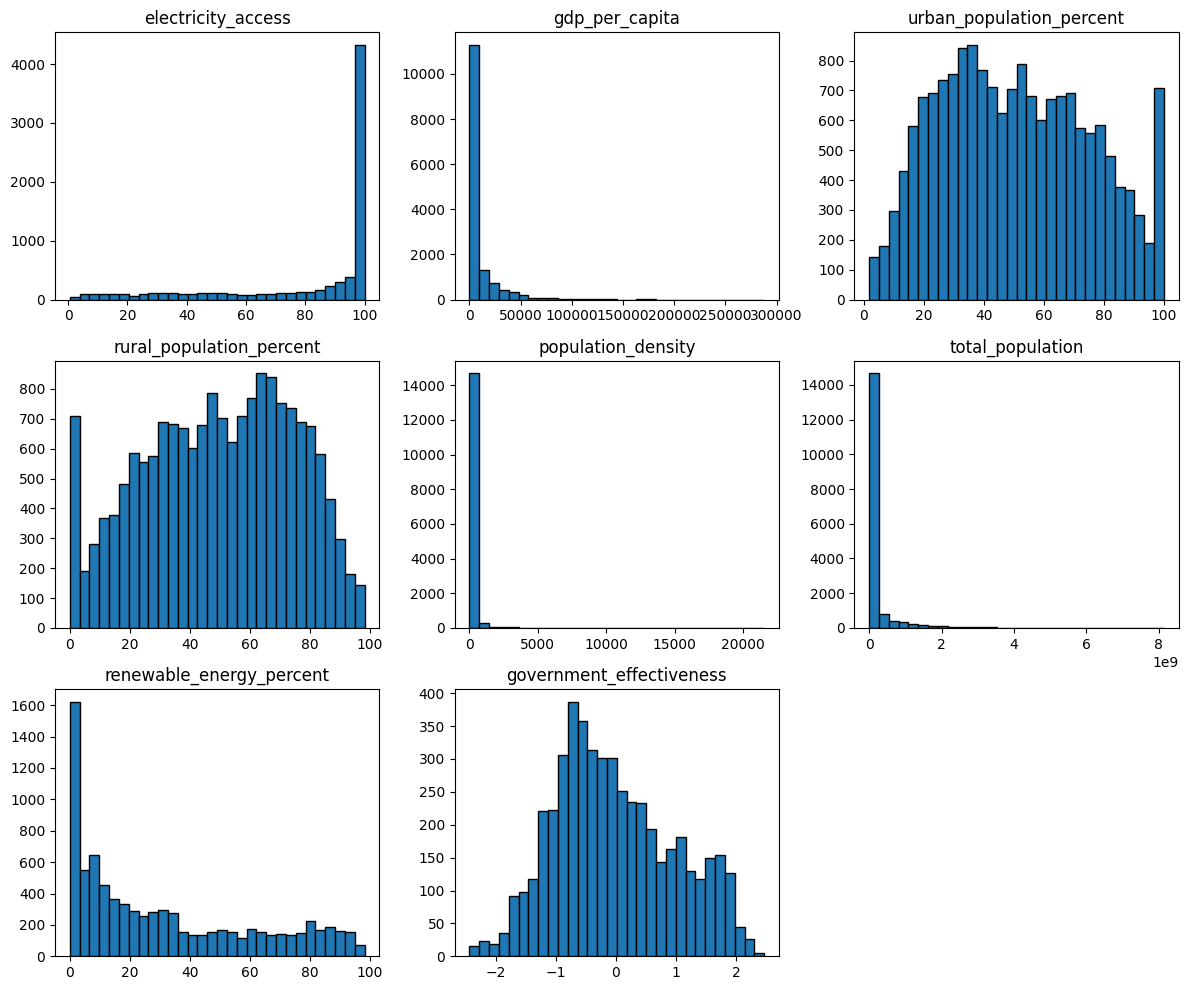

In [335]:
# Select only numeric columns (excluding year)
numeric_cols = merged_df.select_dtypes(include=['number']).columns.tolist()

# Remove 'year' from the list
if 'year' in numeric_cols:
    numeric_cols.remove('year')

# Create histograms with custom color
merged_df[numeric_cols].hist(
    figsize=(12, 10),
    bins=30,
    grid=False,
    edgecolor="black"
)

plt.tight_layout()
plt.show()


In [336]:
# Calculate skewness for all numeric columns to identify distribution asymmetry
merged_df.skew(numeric_only=True)

electricity_access         -1.389217
gdp_per_capita              4.661264
urban_population_percent    0.197213
rural_population_percent   -0.197213
population_density          9.742530
total_population            5.596873
renewable_energy_percent    0.734500
government_effectiveness    0.291337
dtype: float64

In [337]:
# Calculate kurtosis for all numeric columns to measure tail heaviness
merged_df.kurt(numeric_only=True)

electricity_access            0.535874
gdp_per_capita               33.963285
urban_population_percent     -0.908323
rural_population_percent     -0.908323
population_density          103.517160
total_population             37.901911
renewable_energy_percent     -0.801441
government_effectiveness     -0.654507
dtype: float64

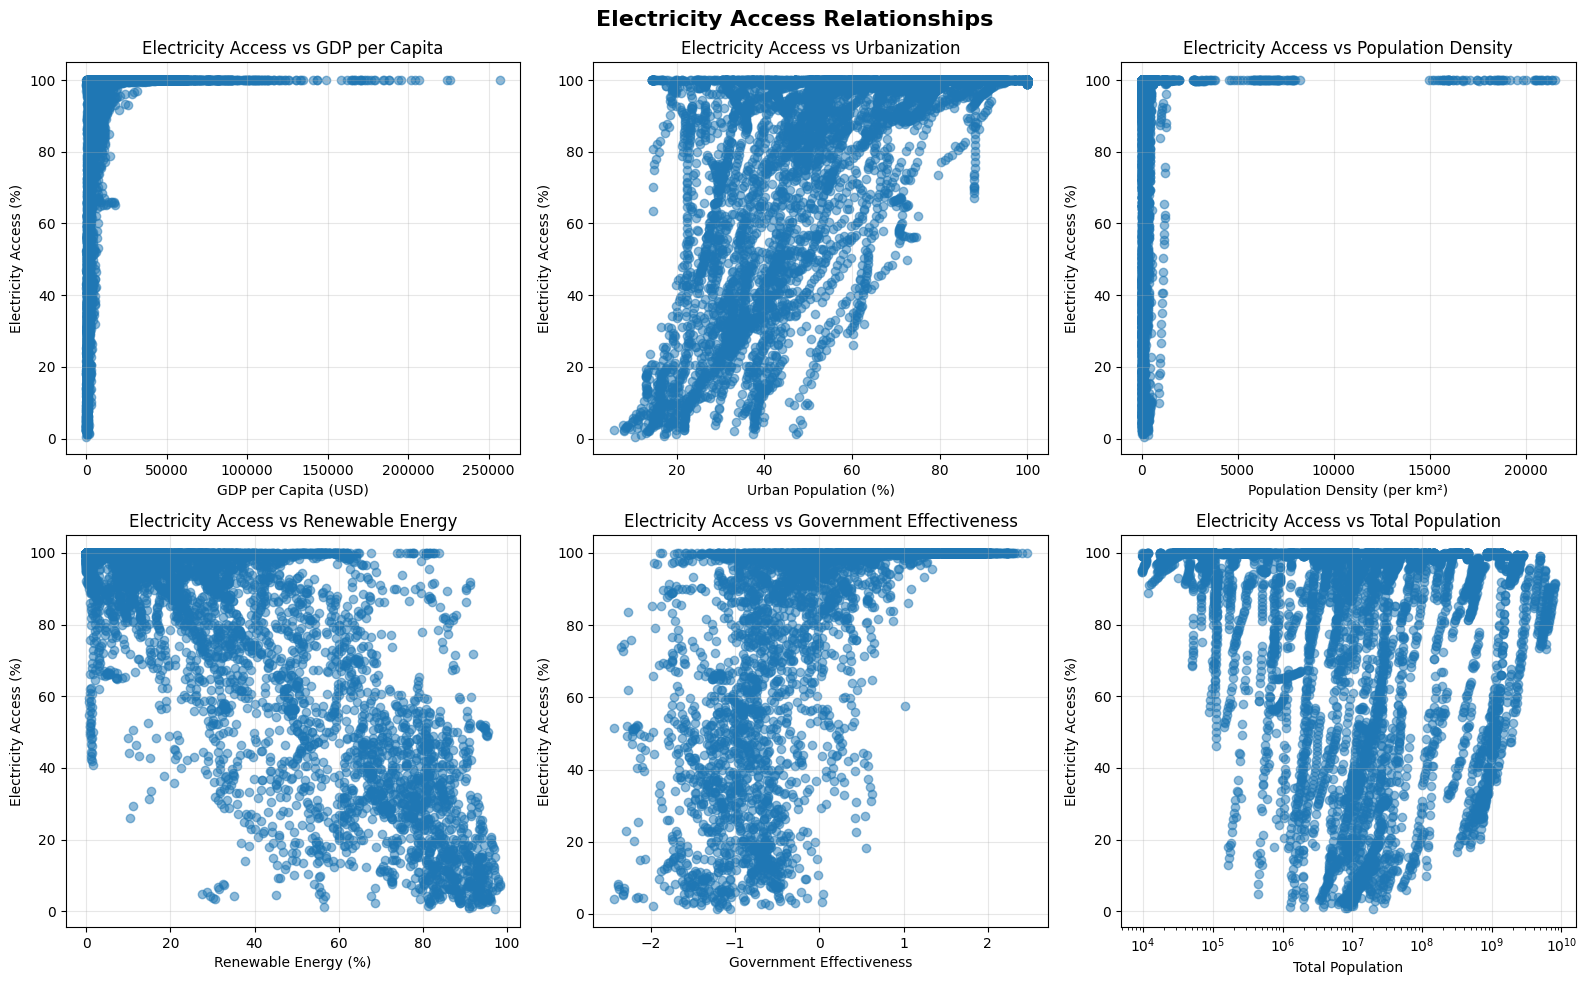

In [338]:
# Connect to database
conn = sqlite3.connect("energy_poverty.db")

# Load data
df_indicators = pd.read_sql_query("SELECT * FROM indicators", conn)
df_countries = pd.read_sql_query("SELECT * FROM countries", conn)

# Merge datasets
df = df_indicators.merge(df_countries, on='country_code', how='left')

# Create scatter plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Electricity Access Relationships', fontsize=16, fontweight='bold')

# Plot 1: GDP
axes[0, 0].scatter(df["gdp_per_capita"], df["electricity_access"], alpha=0.5)
axes[0, 0].set_xlabel("GDP per Capita (USD)")
axes[0, 0].set_ylabel("Electricity Access (%)")
axes[0, 0].set_title("Electricity Access vs GDP per Capita")
axes[0, 0].grid(alpha=0.3)

# Plot 2: Urbanization
axes[0, 1].scatter(df["urban_population_percent"], df["electricity_access"], alpha=0.5)
axes[0, 1].set_xlabel("Urban Population (%)")
axes[0, 1].set_ylabel("Electricity Access (%)")
axes[0, 1].set_title("Electricity Access vs Urbanization")
axes[0, 1].grid(alpha=0.3)

# Plot 3: Population Density
axes[0, 2].scatter(df["population_density"], df["electricity_access"], alpha=0.5)
axes[0, 2].set_xlabel("Population Density (per km²)")
axes[0, 2].set_ylabel("Electricity Access (%)")
axes[0, 2].set_title("Electricity Access vs Population Density")
axes[0, 2].grid(alpha=0.3)

# Plot 4: Renewable Energy
axes[1, 0].scatter(df["renewable_energy_percent"], df["electricity_access"], alpha=0.5)
axes[1, 0].set_xlabel("Renewable Energy (%)")
axes[1, 0].set_ylabel("Electricity Access (%)")
axes[1, 0].set_title("Electricity Access vs Renewable Energy")
axes[1, 0].grid(alpha=0.3)

# Plot 5: Government Effectiveness
axes[1, 1].scatter(df["government_effectiveness"], df["electricity_access"], alpha=0.5)
axes[1, 1].set_xlabel("Government Effectiveness")
axes[1, 1].set_ylabel("Electricity Access (%)")
axes[1, 1].set_title("Electricity Access vs Government Effectiveness")
axes[1, 1].grid(alpha=0.3)

# Plot 6: Total Population (log scale recommended)
axes[1, 2].scatter(df["total_population"], df["electricity_access"], alpha=0.5)
axes[1, 2].set_xlabel("Total Population")
axes[1, 2].set_ylabel("Electricity Access (%)")
axes[1, 2].set_title("Electricity Access vs Total Population")
axes[1, 2].set_xscale('log')  # Log scale for better visualization
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Close connection
conn.close()

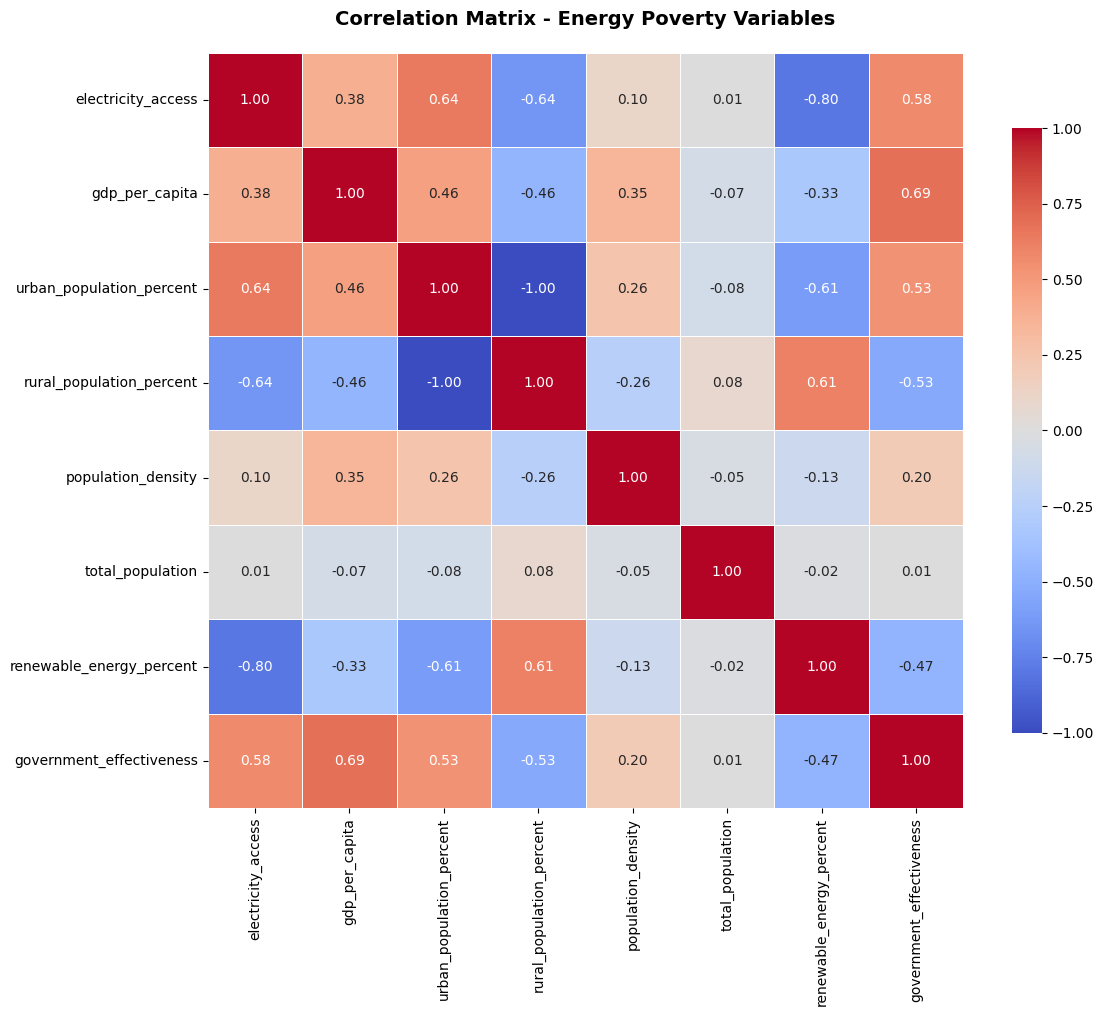

In [339]:
# Calculate correlation matrix (excluding year)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'year' in numeric_cols:
    numeric_cols.remove('year')

corr = df[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, 
            annot=True,           # Show correlation values
            fmt='.2f',            # Format to 2 decimal places
            cmap='coolwarm',         # Grey colormap (matches your style)
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            linewidths=0.5,       # Lines between cells
            cbar_kws={"shrink": 0.8})  # Colorbar size

plt.title("Correlation Matrix - Energy Poverty Variables", 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [340]:
# Focus on correlations with electricity access (target variable)
target = "electricity_access"
correlations = corr[target].drop(target)
correlations_sorted = correlations.sort_values(ascending=False)

print("Correlations with Electricity Access:")
print("="*60)
print(correlations_sorted)

Correlations with Electricity Access:
urban_population_percent    0.642811
government_effectiveness    0.576522
gdp_per_capita              0.383428
population_density          0.103633
total_population            0.006319
rural_population_percent   -0.642811
renewable_energy_percent   -0.804609
Name: electricity_access, dtype: float64


In [ ]:
# Select features for comparison (exclude target and identifiers)
feature_cols = ['gdp_per_capita', 'urban_population_percent', 
                'population_density', 'government_effectiveness']

# Get most recent year data for each country (2023)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
latest_complete_year = df.dropna(subset=feature_cols)['year'].max()
df_recent = df[df['year'] == latest_complete_year]

# Standardize features (important for distance calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_recent[feature_cols])

# Calculate pairwise distances
distances = pdist(X_scaled, metric='euclidean')
distance_matrix = squareform(distances)

# Create distance dataframe
distance_df = pd.DataFrame(
    distance_matrix,
    index=df_recent['country_name'].values,
    columns=df_recent['country_name'].values
)

# Find countries most similar to USA
if 'United States' in distance_df.index:
    similar_to_usa = distance_df['United States'].sort_values().head(6)
    print("Countries most similar to United States:")
    print(similar_to_usa)

Countries most similar to United States:
United States    0.000000
Norway           0.636971
Australia        0.722409
Iceland          0.724733
Germany          0.861294
Qatar            0.877685
Name: United States, dtype: float64


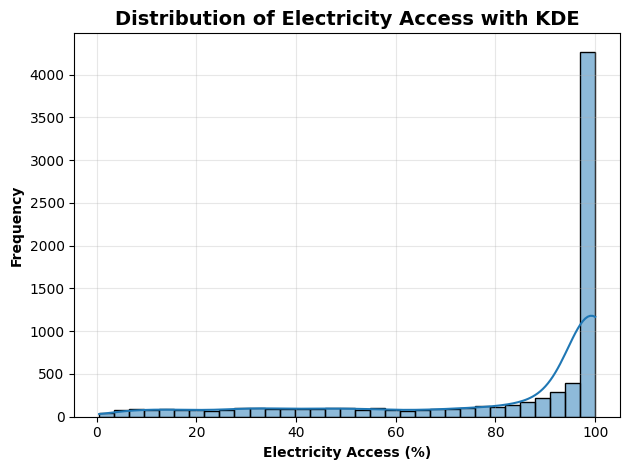

In [342]:

# Connect to your database
conn = sqlite3.connect("energy_poverty.db")

# Load the indicators table
df_indicators = pd.read_sql_query("SELECT * FROM indicators", conn)

# Create KDE histogram for electricity access
sns.histplot(df_indicators["electricity_access"], 
             kde=True,
             edgecolor='black')
plt.xlabel("Electricity Access (%)", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.title("Distribution of Electricity Access with KDE", fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Close connection
conn.close()

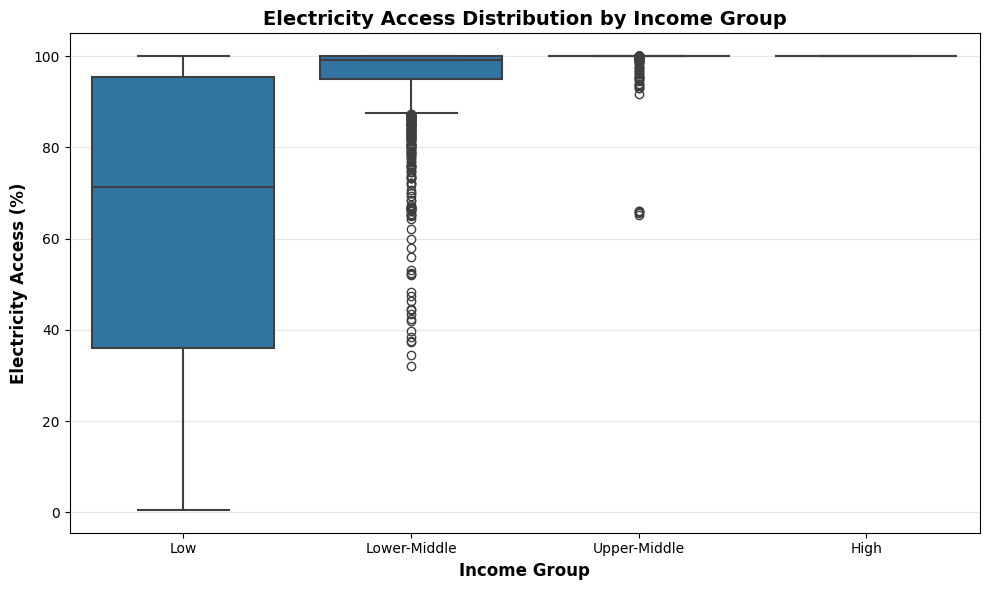

In [343]:
# Connect to database
conn = sqlite3.connect("energy_poverty.db")

# Load data
df_indicators = pd.read_sql_query("SELECT * FROM indicators", conn)
df_countries = pd.read_sql_query("SELECT * FROM countries", conn)

# Merge datasets
df = df_indicators.merge(df_countries, on='country_code', how='left')

# Create income categories based on GDP per capita
df['income_group'] = pd.cut(df['gdp_per_capita'], 
                            bins=[0, 5000, 15000, 50000, 300000],
                            labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

# Box plot: Electricity Access by Income Group
plt.figure(figsize=(10, 6))
sns.boxplot(x="income_group", y="electricity_access", data=df, linewidth=1.5)
plt.xlabel('Income Group', fontweight='bold', fontsize=12)
plt.ylabel('Electricity Access (%)', fontweight='bold', fontsize=12)
plt.title('Electricity Access Distribution by Income Group', 
         fontweight='bold', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

conn.close()

## Data Preprocessing 

In [344]:
# Drop unwanted "Unnamed" columns
electricity_access_df = electricity_access_df.loc[:, ~electricity_access_df.columns.str.contains("Unnamed")]
gdp_df = gdp_df.loc[:, ~gdp_df.columns.str.contains("Unnamed")]
urban_population_df = urban_population_df.loc[:, ~urban_population_df.columns.str.contains("Unnamed")]
rural_population_df = rural_population_df.loc[:, ~rural_population_df.columns.str.contains("Unnamed")]
population_density_df = population_density_df.loc[:, ~population_density_df.columns.str.contains("Unnamed")]
total_population_df = total_population_df.loc[:, ~total_population_df.columns.str.contains("Unnamed")]
renewable_energy_df = renewable_energy_df.loc[:, ~renewable_energy_df.columns.str.contains("Unnamed")]
government_effectiveness_df = government_effectiveness_df.loc[:, ~government_effectiveness_df.columns.str.contains("Unnamed")]

In [345]:
# Identify and remove non-country entries
non_countries = [
    "World", "High income", "Low income", "Middle income", "Lower middle income", "Upper middle income",
    "Low & middle income", "Early-demographic dividend", "Late-demographic dividend", "Post-demographic dividend",
    "Pre-demographic dividend", "Europe & Central Asia", "Sub-Saharan Africa", "Latin America & Caribbean",
    "Arab World", "North America", "South Asia", "OECD members", "Small states", "Other small states",
    "Pacific island small states", "Euro area", "European Union", "Fragile and conflict affected situations",
    "Heavily indebted poor countries (HIPC)", "IBRD only", "IDA total", "IDA & IBRD total", "IDA blend", "IDA only",
    "East Asia & Pacific", "East Asia & Pacific (IDA & IBRD countries)", "East Asia & Pacific (excluding high income)",
    "Europe & Central Asia (IDA & IBRD countries)", "Europe & Central Asia (excluding high income)",
    "Latin America & Caribbean (excluding high income)", "Latin America & the Caribbean (IDA & IBRD countries)",
    "Middle East, North Africa, Afghanistan & Pakistan", 
    "Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)",
    "Middle East, North Africa, Afghanistan & Pakistan (excluding high income)",
    "Sub-Saharan Africa (IDA & IBRD countries)", "Sub-Saharan Africa (excluding high income)",
    "Africa Eastern and Southern", "Africa Western and Central", "Caribbean small states", 
    "Central Europe and the Baltics"
]

# Filter out non-country entries from each dataset
electricity_access_df = electricity_access_df[~electricity_access_df["Country Name"].isin(non_countries)]
gdp_df = gdp_df[~gdp_df["Country Name"].isin(non_countries)]
urban_population_df = urban_population_df[~urban_population_df["Country Name"].isin(non_countries)]
rural_population_df = rural_population_df[~rural_population_df["Country Name"].isin(non_countries)]
population_density_df = population_density_df[~population_density_df["Country Name"].isin(non_countries)]
total_population_df = total_population_df[~total_population_df["Country Name"].isin(non_countries)]
renewable_energy_df = renewable_energy_df[~renewable_energy_df["Country Name"].isin(non_countries)]
government_effectiveness_df = government_effectiveness_df[~government_effectiveness_df["Country Name"].isin(non_countries)]

In [346]:
# Inspect columns
print(electricity_access_df.columns)
print(gdp_df.columns)
print(urban_population_df.columns)
print(rural_population_df.columns)
print(population_density_df.columns)
print(total_population_df.columns)
print(renewable_energy_df.columns)
print(government_effectiveness_df.columns)

# Keep only necessary columns: Country Name, Country Code, and all years (1960 onwards)
# Drop Indicator Name and Indicator Code
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in electricity_access_df.columns if col.isdigit()]
electricity_access_df = electricity_access_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in urban_population_df.columns if col.isdigit()]
urban_population_df = urban_population_df[cols_to_keep]                     
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in rural_population_df.columns if col.isdigit()]
rural_population_df = rural_population_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in population_density_df.columns if col.isdigit()]
population_density_df = population_density_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in total_population_df.columns if col.isdigit()]
total_population_df = total_population_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in renewable_energy_df.columns if col.isdigit()]
renewable_energy_df = renewable_energy_df[cols_to_keep]
cols_to_keep = ['Country Name', 'Country Code'] + [col for col in government_effectiveness_df.columns if col.isdigit()]
government_effectiveness_df = government_effectiveness_df[cols_to_keep] 

# Rename columns for convenience
electricity_access_df.columns = electricity_access_df.columns.str.strip()
electricity_access_df = electricity_access_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
gdp_df.columns = gdp_df.columns.str.strip()
gdp_df = gdp_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
urban_population_df.columns = urban_population_df.columns.str.strip()
urban_population_df = urban_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
rural_population_df.columns = rural_population_df.columns.str.strip()
rural_population_df = rural_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
population_density_df.columns = population_density_df.columns.str.strip()
population_density_df = population_density_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
total_population_df.columns = total_population_df.columns.str.strip()
total_population_df = total_population_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
renewable_energy_df.columns = renewable_energy_df.columns.str.strip()
renewable_energy_df = renewable_energy_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})
government_effectiveness_df.columns = government_effectiveness_df.columns.str.strip()
government_effectiveness_df = government_effectiveness_df.rename(columns={'Country Name': 'country', 'Country Code': 'country_code'})   


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='str')
Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1

In [347]:
# Reshape electricity access dataset from wide to long format
electricity_access_df_long = electricity_access_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="electricity_access"
)
gdp_df_long = gdp_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="gdp_per_capita"
)
urban_population_df_long = urban_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],  
    var_name="year",
    value_name="urban_population_percent"
)
rural_population_df_long = rural_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="rural_population_percent"
)
population_density_df_long = population_density_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="population_density"
)
total_population_df_long = total_population_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],
    var_name="year",
    value_name="total_population"
)
renewable_energy_df_long = renewable_energy_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],  
    var_name="year",
    value_name="renewable_energy_percent"
)
government_effectiveness_df_long = government_effectiveness_df.melt(
    id_vars=[
        "country",
        "country_code",
    ],      
    var_name="year",
    value_name="government_effectiveness"
)
# Convert year column to integer
electricity_access_df_long["year"] = electricity_access_df_long["year"].astype(int)
gdp_df_long["year"] = gdp_df_long["year"].astype(int)
urban_population_df_long["year"] = urban_population_df_long["year"].astype(int)
rural_population_df_long["year"] = rural_population_df_long["year"].astype(int)
population_density_df_long["year"] = population_density_df_long["year"].astype(int)
total_population_df_long["year"] = total_population_df_long["year"].astype(int)
renewable_energy_df_long["year"] = renewable_energy_df_long["year"].astype(int)
government_effectiveness_df_long["year"] = government_effectiveness_df_long["year"].astype(int)

# Convert electricity_access to numeric (some cells might be empty strings)
electricity_access_df_long['electricity_access'] = pd.to_numeric(electricity_access_df_long['electricity_access'], errors='coerce')
gdp_df_long['gdp_per_capita'] = pd.to_numeric(gdp_df_long['gdp_per_capita'], errors='coerce')
urban_population_df_long['urban_population_percent'] = pd.to_numeric(urban_population_df_long['urban_population_percent'], errors='coerce')
rural_population_df_long['rural_population_percent'] = pd.to_numeric(rural_population_df_long['rural_population_percent'], errors='coerce')     
population_density_df_long['population_density'] = pd.to_numeric(population_density_df_long['population_density'], errors='coerce')
total_population_df_long['total_population'] = pd.to_numeric(total_population_df_long['total_population'], errors='coerce')
renewable_energy_df_long['renewable_energy_percent'] = pd.to_numeric(renewable_energy_df_long['renewable_energy_percent'], errors='coerce')
government_effectiveness_df_long['government_effectiveness'] = pd.to_numeric(government_effectiveness_df_long['government_effectiveness'], errors='coerce')


# Sort by country and year
electricity_access_df_long = electricity_access_df_long.sort_values(['country', 'year']).reset_index(drop=True)
gdp_df_long = gdp_df_long.sort_values(['country', 'year']).reset_index(drop=True)
urban_population_df_long = urban_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
rural_population_df_long = rural_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
population_density_df_long = population_density_df_long.sort_values(['country', 'year']).reset_index(drop=True)
total_population_df_long = total_population_df_long.sort_values(['country', 'year']).reset_index(drop=True)
renewable_energy_df_long = renewable_energy_df_long.sort_values(['country', 'year']).reset_index(drop=True)
government_effectiveness_df_long = government_effectiveness_df_long.sort_values(['country', 'year']).reset_index(drop=True)


In [348]:
# Keep only 1990 and later
electricity_access_df_long = electricity_access_df_long[electricity_access_df_long['year'] >= 1990].reset_index(drop=True)
gdp_df_long = gdp_df_long[gdp_df_long['year'] >= 1990].reset_index(drop=True)
urban_population_df_long = urban_population_df_long[urban_population_df_long['year'] >= 1990].reset_index(drop=True)
rural_population_df_long = rural_population_df_long[rural_population_df_long['year'] >= 1990].reset_index(drop=True)
population_density_df_long = population_density_df_long[population_density_df_long['year'] >= 1990].reset_index(drop=True)
total_population_df_long = total_population_df_long[total_population_df_long['year'] >= 1990].reset_index(drop=True)
renewable_energy_df_long = renewable_energy_df_long[renewable_energy_df_long['year'] >= 1990].reset_index(drop=True)
government_effectiveness_df_long = government_effectiveness_df_long[government_effectiveness_df_long['year'] >= 1990].reset_index(drop=True)


In [349]:

print(electricity_access_df_long.head(10))
print(gdp_df_long.head(10))
print(urban_population_df_long.head(10))
print(rural_population_df_long.head(10))
print(population_density_df_long.head(10))
print(total_population_df_long.head(10))
print(renewable_energy_df_long.head(10))
print(government_effectiveness_df_long.head(10))


       country country_code  year  electricity_access
0  Afghanistan          AFG  1990                 NaN
1  Afghanistan          AFG  1991                 NaN
2  Afghanistan          AFG  1992                 NaN
3  Afghanistan          AFG  1993                 NaN
4  Afghanistan          AFG  1994                 NaN
5  Afghanistan          AFG  1995                 NaN
6  Afghanistan          AFG  1996                 NaN
7  Afghanistan          AFG  1997                 NaN
8  Afghanistan          AFG  1998                 NaN
9  Afghanistan          AFG  1999                 NaN
       country country_code  year  gdp_per_capita
0  Afghanistan          AFG  1990             NaN
1  Afghanistan          AFG  1991             NaN
2  Afghanistan          AFG  1992             NaN
3  Afghanistan          AFG  1993             NaN
4  Afghanistan          AFG  1994             NaN
5  Afghanistan          AFG  1995             NaN
6  Afghanistan          AFG  1996             NaN
7  Afg

In [350]:
# Interpolate missing electricity access values per country over years:
# - Linear interpolation estimates missing values between known years
# - Forward-fill fills any remaining gaps using the previous year's value
# - Backward-fill fills gaps at the start using the next available year's value

electricity_access_df_long['electricity_access'] = (
    electricity_access_df_long
    .groupby('country')['electricity_access']
    .apply(lambda x: x.interpolate(method='linear').ffill().bfill())
    .reset_index(level=0, drop=True)
)

# Fill missing GDP values with the median to handle missing data without being affected by outliers
gdp_df_long['gdp_per_capita'] = gdp_df_long['gdp_per_capita'].fillna(gdp_df_long['gdp_per_capita'].median())

# Fill missing Urban Population % values with the median for a robust estimate
urban_population_df_long['urban_population_percent'] = urban_population_df_long['urban_population_percent'].fillna(urban_population_df_long['urban_population_percent'].median())

# Fill missing Rural Population % values with the median
rural_population_df_long['rural_population_percent'] = rural_population_df_long['rural_population_percent'].fillna(rural_population_df_long['rural_population_percent'].median())

# Fill missing Population Density values with the median to reduce skew impact
population_density_df_long['population_density'] = population_density_df_long['population_density'].fillna(population_density_df_long['population_density'].median())

# Fill missing Total Population values with the median
total_population_df_long['total_population'] = total_population_df_long['total_population'].fillna(total_population_df_long['total_population'].median())

# Fill missing Renewable Energy % values with the median
renewable_energy_df_long['renewable_energy_percent'] = renewable_energy_df_long['renewable_energy_percent'].fillna(renewable_energy_df_long['renewable_energy_percent'].median())

# Fill missing Government Effectiveness Index values with the median
government_effectiveness_df_long['government_effectiveness'] = government_effectiveness_df_long['government_effectiveness'].fillna(government_effectiveness_df_long['government_effectiveness'].median())




In [351]:
# Save cleaned and reshaped datasets to new CSV files for future use
electricity_access_df_long.to_csv("data/processed/electricity_access_long.csv", index=False)
gdp_df_long.to_csv("data/processed/gdp_long.csv", index=False)
urban_population_df_long.to_csv("data/processed/urban_population_long.csv", index=False)
rural_population_df_long.to_csv("data/processed/rural_population_long.csv", index=False)
population_density_df_long.to_csv("data/processed/population_density_long.csv", index=False)
total_population_df_long.to_csv("data/processed/total_population_long.csv", index=False)
renewable_energy_df_long.to_csv("data/processed/renewable_energy_long.csv", index=False)
government_effectiveness_df_long.to_csv("data/processed/government_effectiveness_long.csv", index=False)


In [352]:
# Merge all datasets into a single dataframe for modeling

merged_df = electricity_access_df_long[['country', 'year', 'electricity_access']]
merged_df = merged_df.merge(gdp_df_long[['country', 'year', 'gdp_per_capita']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(urban_population_df_long[['country', 'year', 'urban_population_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(rural_population_df_long[['country', 'year', 'rural_population_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(population_density_df_long[['country', 'year', 'population_density']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(total_population_df_long[['country', 'year', 'total_population']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(renewable_energy_df_long[['country', 'year', 'renewable_energy_percent']], on=['country', 'year'], how='left')
merged_df = merged_df.merge(government_effectiveness_df_long[['country', 'year', 'government_effectiveness']], on=['country', 'year'], how='left')

# Save the final merged dataset to a CSV file for modeling
merged_df.to_csv('data/processed/merged_dataset.csv', index=False)